# Starting Kit for the Pollinator Challenge
### Authors: 
* Dominika Chojnacka (gusia02), 
* Youssef El Otmani (youyou354), 
* Krisa Carka (kcarka), 
* Raphael Leonardi (raphleonardi), 
* Marina Hornero Merino (55horner0)
* Frederic Busch (frederic)

This Starting Kit will guide you through all the steps in order to successfully complete the Pollinator Challenge. It consists of sections with the introduction to the Challenge, dataset desciption, baseline model, performance metrics, and making a submission.

[GitHub link](https://github.com/Group4-AI-Challenge/pollinator2-Challenge-M1-AI/tree/main)

# The Challenge

In this challenge, your task will be to identify types of pollinators from images of flowers. Images may not contain any pollinator or one of the eight types of pollinators. Correctly identifying the pollinator species ifs important becasue different insects play differnt role in ecosystems. Missclassifying them may lead to incorrect conclusiosn about behavior of specific-species, therefore, harmful human influences to these ecosystems.

### Description of the data

The dataset consists of images extracted from videos of flowers. Each image may contain one of eight pollinator species or no pollinator at all. Images are captured from different recording angles. During training, data from only one angle is provided. The objective of the challenge is to correctly classify the pollinators present in the images.

The dataset contains nine distinct classes with labels: 0, 2, 3, 4, 5, 6, 7, 9, and 10. Label 0 corresponds to images without a pollinator, while the remaining labels represent different pollinator species (for example, a burbon or a butterfly, illustrated in the first two images below). 

Two key characteristics of the data should be highlighted. First, since the images are extracted from videos, many consecutive frames depict nearly identical views of a pollinator during a single visitation. We refer to such groups of similar images as a sequence, as illustrated in Videos 3 and 4. Second, the data were recorded from multiple angles, which introduces significant viewpoint variation across samples.

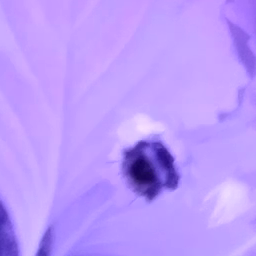
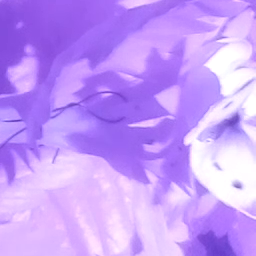
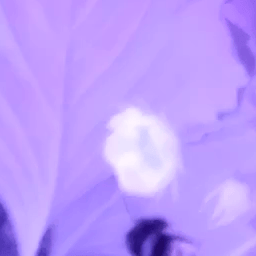
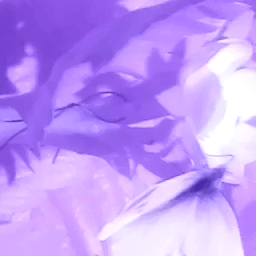


### Train-test split

The train–test split was designed to prevent data leakage. For each, specie we ensure that the images taken from the same angle do not appear in both the training and testing sets. This comes from the fact that two images taken from the same angle are almost identical. This would cause a great amount of data leakage if the angles were not separated correctly. Consequently, although all nine labels are present in the training data, no pollinator instance recorded from the same sequence and angle appears in the test set.




This splitting strategy resulted in approximately 78% of the data being allocated to the training set, corresponding to 3953 samples, with the remaining 1159 samples used for testing. Additionally, care was taken to ensure that all pollinator classes are represented in both the training and test sets.

Original angles by species: 

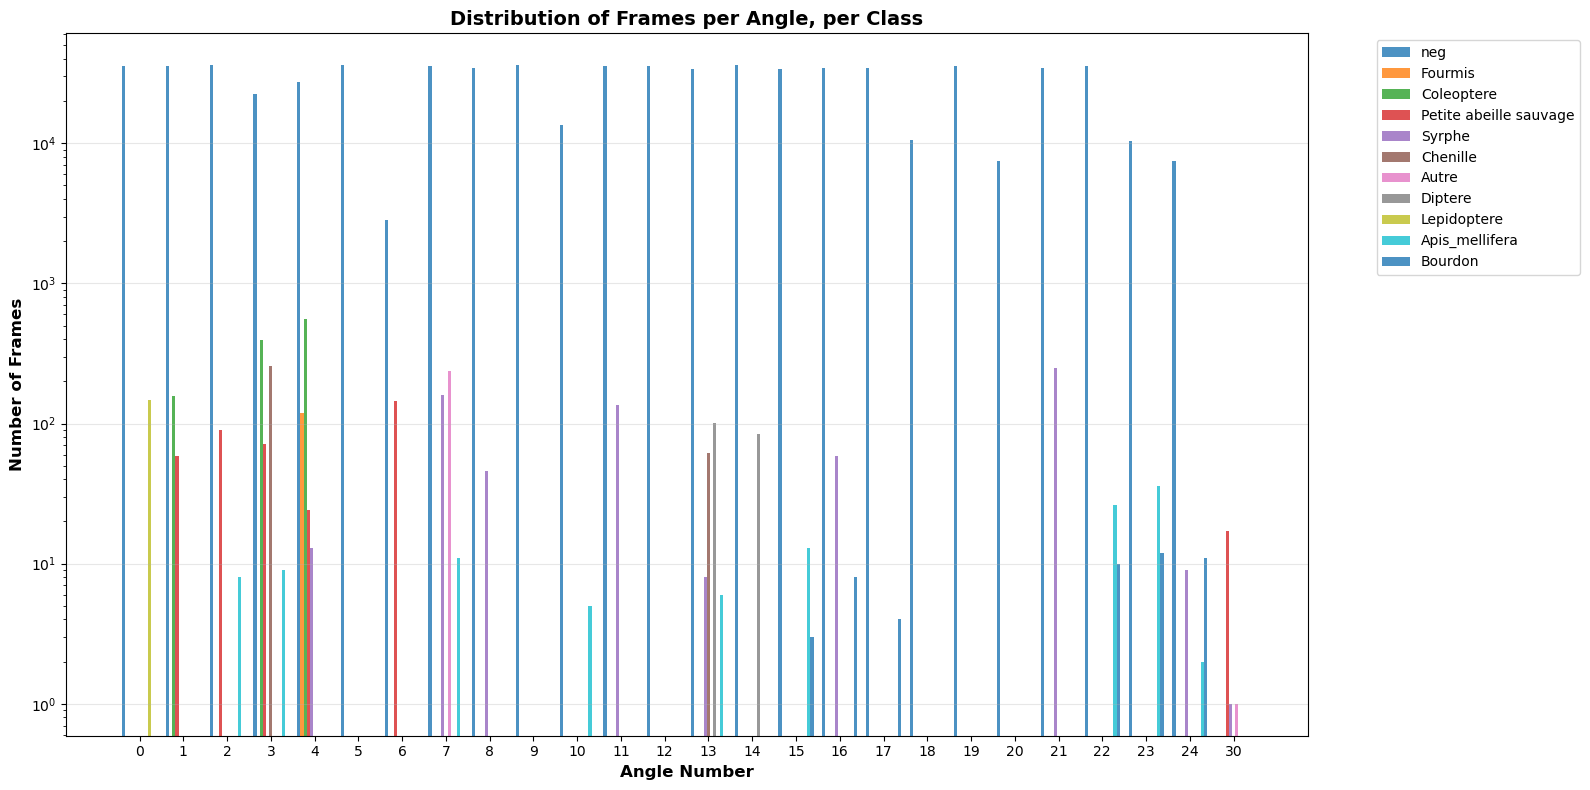

### Evaluation

The evaluation is performed in two phases: one public and one hidden. For both you will be tested on images of insects seen from the same angles as in the training. During the first phase, you will be able to see your score and resubmit your model. However, during the second, you will not be able to resubmit the model. You will get a final score evaluated with different data than the first, but also on angles seen during training. This is made to ensure your model is robust to different situations.

# 0 - Preliminary

## 0.1 - Running in Colab vs Running locally

`COLAB` determines whether this notebook is running on Google Colab. If so, it clones the GitHub repository and moves you into the correct folder. This is equivalent to downloading the starting kit to your local machine.
* If working on Colab: Simply run the setup cell below and continue.
* If working locally: Ensure you have the entire Starting Kit folder downloaded and that this notebook is located inside that folder.

In [1]:
CLASSES = {0: 'neg', 2: 'Coleoptere', 
           3: 'Petite abeille sauvage', 4: 'Syrphe', 5: 'Chenille', 
           6: 'Autre', 7: 'Diptere', 9: 'Apis mellifera',
           10: 'Bourdon'}
COLAB = 'google.colab' in str(get_ipython())

In [2]:
if COLAB:
    # clone github repo
    !git clone --depth 1 https://github.com/Group4-AI-Challenge/pollinator2-Challenge-M1-AI
    # move to the starting kit folder
    %cd pollinator2-Challenge-M1-AI/Starting_Kit/

## 0.2 - Imports & Settings

### TODO: add info on requirements

In [3]:
# !pip install -r "requirements.txt"

In [4]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
from PIL import Image
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sys import path
import zipfile
from datetime import datetime
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



import tqdm as tq
%matplotlib inline

# 1 - Data Loading

In [5]:
# note this is just loading the sample code
model_dir = 'sample_code_submission/' # Change the model to a better one once you have one!
path.append(model_dir)
scor_dir = 'scoring_program'
path.append(scor_dir)
data_dir = "data" # this is just some sample code to try on

# loading all the data for training
train_data = { 
    'X_train': np.load(os.path.join(data_dir, "X_train.npy")),
    'y_train': np.load(os.path.join(data_dir, "y_train.npy"))
} 

# loading some sample data for testing
X_test = {'X_test': np.load(os.path.join(data_dir, "X_test.npy"))}
with open(os.path.join(data_dir, "y_test.json"), 'r') as f:
    y_test_dict = json.load(f)

# 2 - Training
We provide an example of predictive model in the `sample_code_submission/` directory.

The baseline model is a KNearestNeighbors classifier. We chose this classifier since it is easy to understand and to experiment with on a first instance.

You may change and tune this model to improve your score in the challenge.

In [6]:
from model import Model
    
myModel = Model()
myModel.fit(train_data)
y_pred = myModel.predict(X_test['X_test'])
y_test = y_test_dict['y_test']

[*] - Initializing Classifier
[*] - Training Classifier on the train set
[*] - Predicting test set using trained Classifier


# 3 - Visualization

### Here you can see see the distribution of the training samples
Here are the label distributions of train samples (X_train):

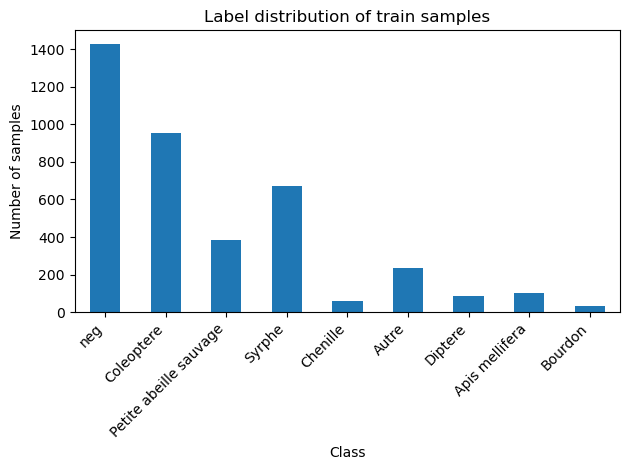

Here is the current distribution of the angles from which the images of the pollinators are taken (note that a whole sequence is taken from one angle only, but there may be multiple pollinators from that angle, so you may use it to train your model on that specific angle).

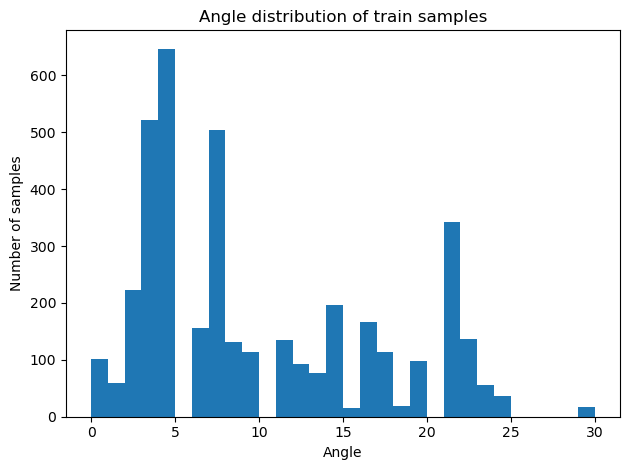

Note, you can reproduce the label distribution by using the code below, which is using just some sample data.

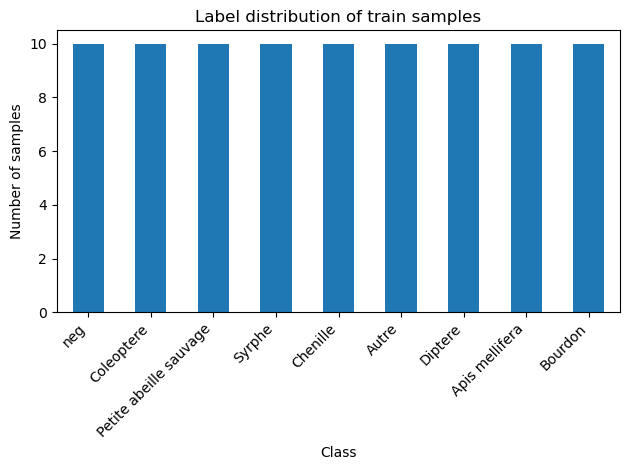

In [7]:
class_ids = list(CLASSES.keys()) 
class_names = list(CLASSES.values()) 
train_counts = (
    pd.Series(train_data['y_train'])
    .value_counts()
    .reindex(class_ids, fill_value=0)
)


df = pd.DataFrame({
    "Train": train_counts.values,
}, index=class_names)


df.plot(kind="bar", legend=False)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Label distribution of train samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Confusion matrix 

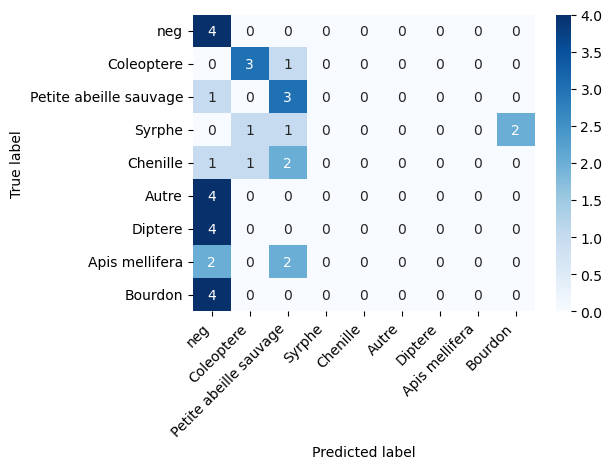

In [8]:
# Note: this is just the confusion matrix for the sample data.
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_ids
)

df_cm = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

sns.heatmap(df_cm, annot=True, fmt=".0f", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 4 - Scoring
Our scoring class uses the macro F1 as the performance metric. We are using this metric since the data is unbalanced towards class 0 (no pollinator in the image), and we want to penalize being wrongly classified. Macro F1 computes the unweighted average of the F1 score for each class, so misclassifying underrepresented classes, such as failing to detect a pollinator when one is present, results in a significant decrease in the overall score.

Note that this score is just for the sample test provided. 

In [ ]:
from score import Scoring

myScor = Scoring()
myScor.reference_data = y_test_dict
myScor.ingestion_result = {'predictions': y_pred}
myScor.compute_scores()
print(myScor.scores_dict)

[*] Computing scores
{'score': 0.1623931623931624}


# 5 - Prepare submission for Codabench

It is important that you change your model in the model.py file inside 'sample_code_submission' in the Starting Kit folder. After you finish modifying the model.py file from sample_code_submission, simply run this cell. It will create a zip file containing the model inside sample_result_submission. Upload the zip file to Codabench, and it will automatically calculate the score.

**Note**: If you only change the model inside of this jupiter notebook, and then zip it, it will not change anything.

In [10]:
current_dir = os.getcwd()
model_file = os.path.join(current_dir, 'sample_code_submission', 'model.py')
output_dir = os.path.join(current_dir, 'sample_result_submission')

os.makedirs(output_dir, exist_ok=True)

the_date = datetime.now().strftime("%y-%m-%d-%H-%M")
zip_filename = f'model_submission_{the_date}.zip'
zip_path = os.path.join(output_dir, zip_filename)

with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write(model_file, arcname='model.py')

print(f"Created zip file:\n{zip_path}")


Created zip file:
c:\Users\seaov\OneDrive - Université Paris-Saclay\T3\AI challenge\pollinator2-Challenge-M1-AI\Starting Kit\sample_result_submission\model_submission_26-02-02-19-23.zip


# 6 - Optional : Splitting the data locally

As we mentionned in the first markdown cell, the training and testing data are splitted so that for each species, the pictures from a given angle do not appear in the training and in the test set. Therefore the splitting cannot just use a simple  ```train_test_split()``` to split the data. If the basic splitting is used, the score will be too high. So if you wish to split your data and train your model locally, use the function we give you so that you don't get a model that will perform bad on the corrected splitted test set on Codabench.
\
\
We are providing you a python file named `split.py` so that the splitting can be done correctly.
The function to use is `split_data()`. This function takes the following arguments : 


- `X` : an array containing the data points you wish to split
- `y` : an array containing the labels of the points.
- `angles` the angles where each photo were taken
- `random_state`: the seed used to shuffle the angles, defaulted to value 42.
- `return_mask` : a boolean set by default to False. If set to True the output will be the training and the test masks.

This function will return the `X_train`,`X_test`,`y_train`,`y_test_`,`angles_train`,`angles_test`, wich is the splitted data.
If return_mask was set to False, the function will return simply the numpy mask `train_mask` and `test_mask`.
